In [1]:
import logging
import os
from datetime import datetime

def debug(msg: str) -> None:
    """Log messages with timestamp."""
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}")

logging.getLogger("kedro.io").setLevel(logging.WARNING)
import numpy as np

np.set_printoptions(suppress=True)
np.random.seed(1)
import random

random.seed(1)
import pandas as pd

pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
import seaborn as sns

sns.set_style("whitegrid")
import matplotlib.pyplot as plt

plt.style.use("ggplot")
plt.rcParams.update(
    {
        "figure.figsize": (8, 5),
        "figure.dpi": 100,
        "savefig.dpi": 300,
        "figure.constrained_layout.use": True,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "legend.title_fontsize": 10,
        "grid.alpha": 1.0,
    }
)
import matplotlib as mpl
from cycler import cycler

mpl.rcParams["axes.prop_cycle"] = cycler(color=["#000000", "#000000"])
mpl.colormaps.register(
    mpl.colors.ListedColormap(["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name="black_and_2color",
    ),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name="black_and_3color",
    ),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name="black_and_4color",
    ),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name="r_colors",
    ),
    force=True,
)

DATA_PATH = "../data/03_primary"

df_anomaly_source = pd.read_csv(
    os.path.join(DATA_PATH, "attributes_anomaly_source_test.csv")
)
df_anomaly_target = pd.read_csv(
    os.path.join(DATA_PATH, "attributes_anomaly_target_test.csv")
)
df_normal_source = pd.read_csv(
    os.path.join(DATA_PATH, "attributes_normal_source_test.csv")
)
df_normal_target = pd.read_csv(
    os.path.join(DATA_PATH, "attributes_normal_target_test.csv")
)

TS_PATH = "../data/03_primary/time_series_data"
train_path = os.path.join(TS_PATH, "train")

df_normal_target_train = pd.read_csv(
    os.path.join(train_path, "attributes_normal_target_train.csv")
)
df_normal_source_train = pd.read_csv(
    os.path.join(train_path, "attributes_normal_source_train.csv")
)

all_data = pd.concat([
    df_anomaly_source,
    df_anomaly_target,
    df_normal_source,
    df_normal_target,
    df_normal_target_train,
    df_normal_source_train
]).reset_index(drop=True)

[09/22/26 22:44:25] WARNING  C:\Users\tmdp1\AppData\Local\Temp\ipykernel_7352\1437810288.py:32:     ]8;id=14229134;file://C:\Users\tmdp1\AppData\Roaming\uv\python\cpython-3.12.11-windows-x86_64-none\Lib\warnings.py\warnings.py]8;;\:]8;id=14229135;file://C:\Users\tmdp1\AppData\Roaming\uv\python\cpython-3.12.11-windows-x86_64-none\Lib\warnings.py#112\112]8;;\
                             UserWarning: The figure layout has changed to tight                                   
                               plt.tight_layout()                                                                  
                                                                                                                   

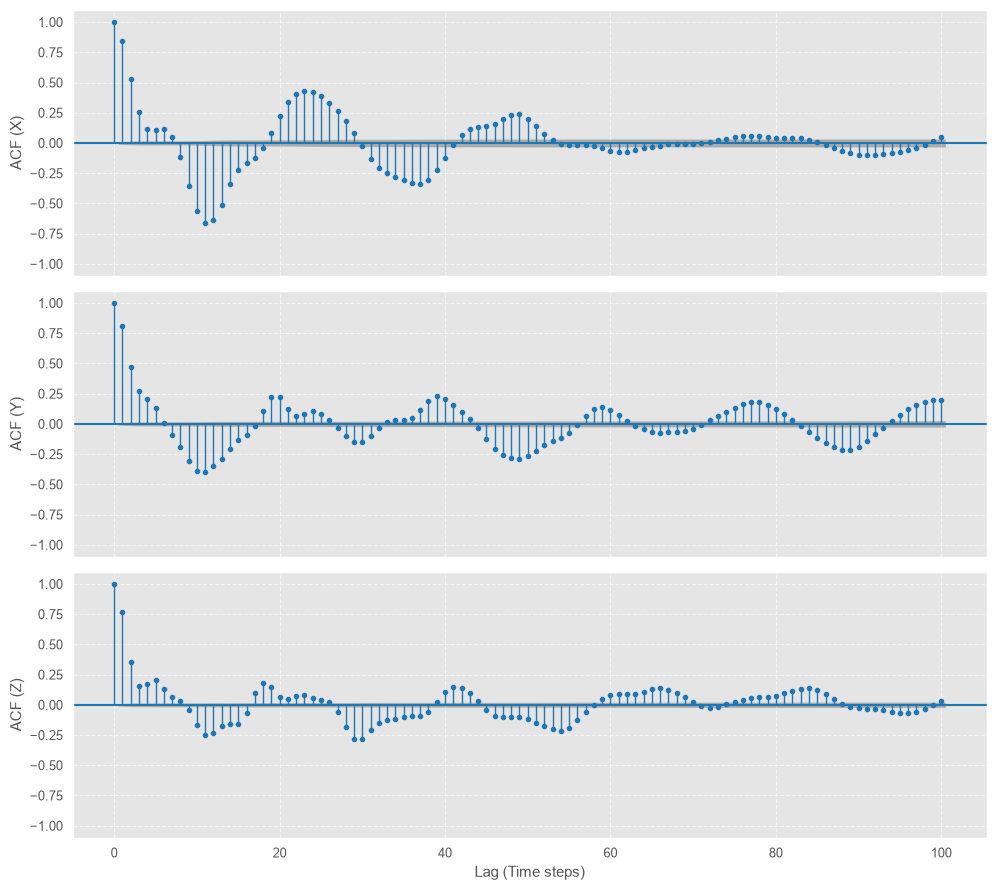

In [28]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

def plot_vibration_autocorrelation_multi(signals_dict, file_path_save, lags=100):
    """
    Computes and plots the Autocorrelation Function (ACF) for multiple 1D time-series signals
    in subplots within the same figure.
    
    Parameters:
    signals_dict (dict): Dictionary with labels and respective signals (e.g., {'X': ts_x, 'Y': ts_y, 'Z': ts_z}).
    file_path_save (str): Path to save the PDF.
    lags (int): Number of time lags to calculate.
    """
    n_signals = len(signals_dict)
    
    # Create a figure with N vertical subplots sharing the X-axis
    fig, axes = plt.subplots(n_signals, 1, figsize=(10, 3 * n_signals), sharex=True)
    
    for ax, (label, signal) in zip(axes, signals_dict.items()):
        plot_acf(signal, lags=lags, alpha=0.05, ax=ax, markersize=3, 
                 title="", color='#1f77b4', 
                 vlines_kwargs={"colors": '#1f77b4', "linewidth": 1})
        
        ax.set_ylabel(f"ACF ({label})", fontsize=11)
        ax.set_ylim([-1.1, 1.1])
        ax.grid(True, linestyle='--', alpha=0.6, zorder=0)
        

    # Set the X-axis label only on the bottom-most subplot
    axes[-1].set_xlabel("Lag (Time steps)", fontsize=11)
    
    plt.tight_layout()
    plt.savefig(file_path_save, format='pdf')
    plt.show()

file_name = all_data[(all_data["anomaly_label"] == "normal") & (all_data["domain_shift_op"] == "spd1400")].reset_index().loc[0, "ism330dhcx_acc"]
split_label = all_data[(all_data["anomaly_label"] == "normal") & (all_data["domain_shift_op"] == "spd1400")].reset_index().loc[0, "split_label"]

folder_path = "train" if str(split_label).endswith("Train") else "test"
    
ts = pd.read_parquet(f"../data/03_primary/time_series_data/{folder_path}/{file_name}").values
ts_x = ts[1:, 1]
ts_y = ts[1:, 2]
ts_z = ts[1:, 3]

signals_to_plot = {
    'X': ts_x,
    'Y': ts_y,
    'Z': ts_z
}

plot_vibration_autocorrelation_multi(signals_to_plot, file_path_save="../data/08_reporting/acf_plot.pdf", lags=100)

[09/22/26 23:31:29] WARNING  C:\Users\tmdp1\AppData\Local\Temp\ipykernel_7352\1331214206.py:33:     ]8;id=14229152;file://C:\Users\tmdp1\AppData\Roaming\uv\python\cpython-3.12.11-windows-x86_64-none\Lib\warnings.py\warnings.py]8;;\:]8;id=14229153;file://C:\Users\tmdp1\AppData\Roaming\uv\python\cpython-3.12.11-windows-x86_64-none\Lib\warnings.py#112\112]8;;\
                             UserWarning: The figure layout has changed to tight                                   
                               plt.tight_layout()                                                                  
                                                                                                                   

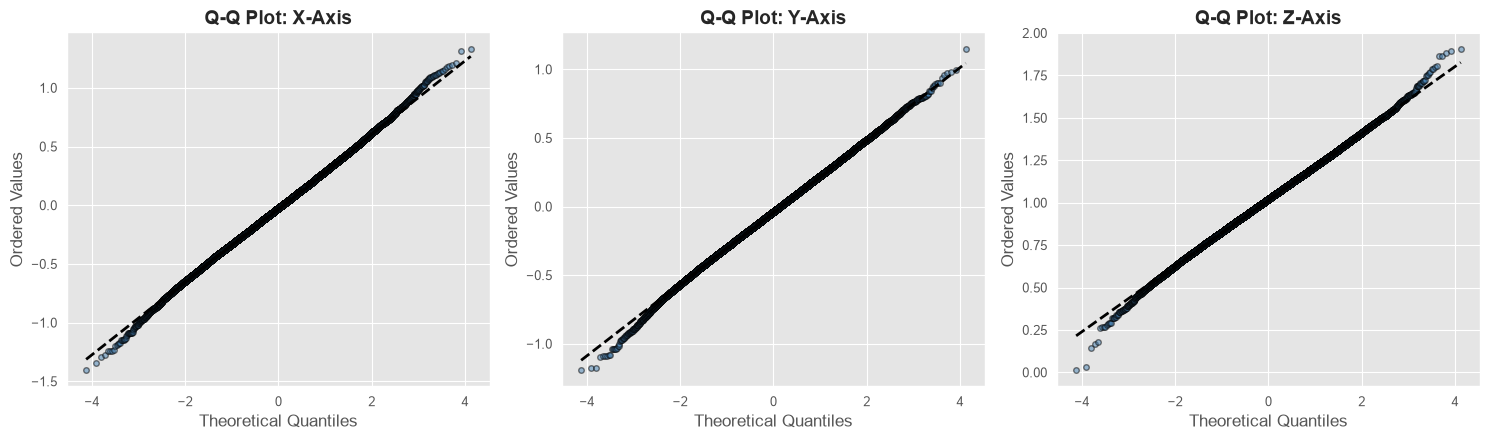

In [34]:
import scipy.stats as stats

file_name = all_data[(all_data["anomaly_label"] == "normal") & (all_data["domain_shift_op"] == "spd1400")].reset_index().loc[0, "ism330dhcx_acc"]
split_label = all_data[(all_data["anomaly_label"] == "normal") & (all_data["domain_shift_op"] == "spd1400")].reset_index().loc[0, "split_label"]

folder_path = "train" if str(split_label).endswith("Train") else "test"
    
ts = pd.read_parquet(f"../data/03_primary/time_series_data/{folder_path}/{file_name}")

axes_labels = ['A_x [g]', 'A_y [g]', 'A_z [g]']
titles = ['X-Axis', 'Y-Axis', 'Z-Axis']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for i, col in enumerate(axes_labels):
    data = ts[col].values[1:]
    
    stats.probplot(data, dist="norm", plot=axes[i])
    
    axes[i].get_lines()[0].set_marker('o')
    axes[i].get_lines()[0].set_markerfacecolor('steelblue')
    axes[i].get_lines()[0].set_markeredgecolor('black')
    axes[i].get_lines()[0].set_markersize(4)
    axes[i].get_lines()[0].set_alpha(0.5)
    axes[i].get_lines()[1].set_color('black') # Linha diagonal preta
    axes[i].get_lines()[1].set_linewidth(2)
    axes[i].get_lines()[1].set_linestyle('--')
    
    axes[i].set_title(f'Q-Q Plot: {titles[i]}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Theoretical Quantiles', fontsize=12)
    axes[i].set_ylabel('Ordered Values', fontsize=12)

plt.tight_layout()
plt.savefig("../data/08_reporting/qq_plots_xyz.pdf", format="pdf", bbox_inches='tight')
plt.show()